### Pretrained Monet2Photo CycleGAN & Image Generation

##### Setting up environment & loading model + data

To begin the initial setup for the pretrained CycleGAN, we first clone the repository and install the required libraries.

In [1]:
# Clone the repository and nanvigate into the directory
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix

c:\Users\Yoshio\OneDrive\Bildung\Master (CBS)\Semester-03\Advanced ML for CV\final_project\Advanced-Machine-Learning-for-Computer-Vision\pytorch-CycleGAN-and-pix2pix


Cloning into 'pytorch-CycleGAN-and-pix2pix'...


In [4]:
# Install needed packages
!pip install torch torchvision torchaudio
!pip install dominate visdom wandb
!pip install kagglehub

  Using cached kagglehub-0.3.13-py3-none-any.whl.metadata (38 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached kagglehub-0.3.13-py3-none-any.whl (68 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]


Next, the checkpoints for the model must be downloaded.

In [10]:
!pip install scikit-image


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 18.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-image] [scikit-image]


In [11]:
from glob import glob

import numpy as np
from skimage.io import imread
from skimage.metrics import structural_similarity


In [5]:
import urllib.request
import zipfile
import os


In [2]:
# Create directory
os.makedirs("checkpoints/monet2photo_pretrained", exist_ok=True)

# Download pretrained model
urllib.request.urlretrieve(
    "http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/monet2photo.pth",
    "checkpoints/monet2photo_pretrained/latest_net_G.pth"
)

('checkpoints/monet2photo_pretrained/latest_net_G.pth',
 <http.client.HTTPMessage at 0x2033df85310>)

Then, the datasets Monet2Photo and Cezanne2Photo are downloaded. Each dataset is saved into a dedicated folder, extracted, and the original zip file is removed to keep the directory clean.

In [4]:
# Download monet2photo
os.makedirs("datasets", exist_ok=True)
urllib.request.urlretrieve(
    "http://efrosgans.eecs.berkeley.edu/cyclegan/datasets/monet2photo.zip",
    "datasets/monet2photo.zip"
)
with zipfile.ZipFile("datasets/monet2photo.zip", 'r') as zip_ref:
    zip_ref.extractall("datasets/")
os.remove("datasets/monet2photo.zip")

Run tests on both datasets and save generated images.

In [9]:
# Test on Monet paintings
%cd pytorch-CycleGAN-and-pix2pix

!python test.py \
  --dataroot datasets/monet2photo/testA \
  --name monet2photo_pretrained \
  --model test \
  --no_dropout \
  --num_test 121 \
  --phase test_monet


/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix
----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: datasets/monet2photo/testA    	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
   

#### Evaluation Metrics - Initial Exploration

##### Structural Similarity Index Measure (SSIM)

SSIM measures image quality by comparing local patterns of luminance, contrast, and structure between two images, reflecting how humans perceive structural changes rather than raw pixel error. Original SSIM paper can be found here: https://www.cns.nyu.edu/pub/lcv/wang03-reprint.pdf

We are calculating SSIM measure to get a first indication how much the original Monet image changed compared to its photorealistic counterpart (the output of the GAN). SSIM assumes pairs as it looks at considers three things (taken from: https://medium.com/@akp83540/structural-similarity-index-ssim-c5862bb2b520). 

*Brightness*: How bright are the pictures overall? Is one picture really dark and the other one really bright?

*Contrast*: How different are the colors next to each other in the pictures? Are the colors in one picture washed out compared to the other?

*Structure*: Are the patterns and shapes in the same places in both pictures? If one picture is blurry, the SSIM would take that into account.


In [12]:
base_dir = "/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix"

images_dir = os.path.join(
    base_dir,
    "results/monet2photo_pretrained/test_monet_latest/images"
)

print(images_dir)


/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/results/monet2photo_pretrained/test_monet_latest/images


In [13]:
# All files that end with "_fake.png"
fake_paths = sorted(glob(os.path.join(images_dir, "*_fake.png")))
print("Number of fake images:", len(fake_paths))

pairs = []

for fake_path in fake_paths:
    filename = os.path.basename(fake_path)     
    real_filename = filename.replace("_fake", "_real")
    real_path = os.path.join(images_dir, real_filename)

    if os.path.exists(real_path):
        pairs.append((fake_path, real_path))
    else:
        print("WARNING: no real image for", fake_path)

print("Number of (fake, real) pairs:", len(pairs))


Number of fake images: 121
Number of (fake, real) pairs: 121


structural_similarity does: 
- slides a small window over both images
- compares luminance, contrast, and local structure inside each window, 
- averages those local scores into one global SSIM value between −1 and 1

In [14]:
ssim_scores = []

for fake_path, real_path in pairs:
    fake_img = imread(fake_path)
    real_img = imread(real_path)
    if fake_img.shape != real_img.shape:
        raise ValueError(f"Size mismatch: {fake_path} vs {real_path}")

    #Compute SSIM for pairs
    score = structural_similarity(
        fake_img,
        real_img,
        channel_axis=-1,  
        data_range=255    
    )

    ssim_scores.append(score)

len(ssim_scores)


121

In [15]:
for (fake_path, real_path), score in list(zip(pairs, ssim_scores))[:10]:
    print(
        os.path.basename(fake_path),
        os.path.basename(real_path),
        f"SSIM = {score:.4f}"
    )


00010_fake.png 00010_real.png SSIM = 0.6080
00020_fake.png 00020_real.png SSIM = 0.4763
00030_fake.png 00030_real.png SSIM = 0.7030
00040_fake.png 00040_real.png SSIM = 0.7866
00050_fake.png 00050_real.png SSIM = 0.7970
00060_fake.png 00060_real.png SSIM = 0.9518
00070_fake.png 00070_real.png SSIM = 0.8228
00080_fake.png 00080_real.png SSIM = 0.5750
00090_fake.png 00090_real.png SSIM = 0.7813
00100_fake.png 00100_real.png SSIM = 0.7022


In [17]:
ssim_scores = np.array(ssim_scores)

mean_ssim = ssim_scores.mean()
std_ssim = ssim_scores.std()
min_ssim = ssim_scores.min()
max_ssim = ssim_scores.max()

print(f"Mean SSIM: {mean_ssim:.3f}")
print(f"Std  SSIM: {std_ssim:.3f}")
print(f"Min  SSIM: {min_ssim:.3f}")
print(f"Max  SSIM: {max_ssim:.3f}")

Mean SSIM: 0.725
Std  SSIM: 0.125
Min  SSIM: 0.362
Max  SSIM: 0.952


Mean SSIM: 0.725
Std  SSIM: 0.125
Min  SSIM: 0.362
Max  SSIM: 0.952


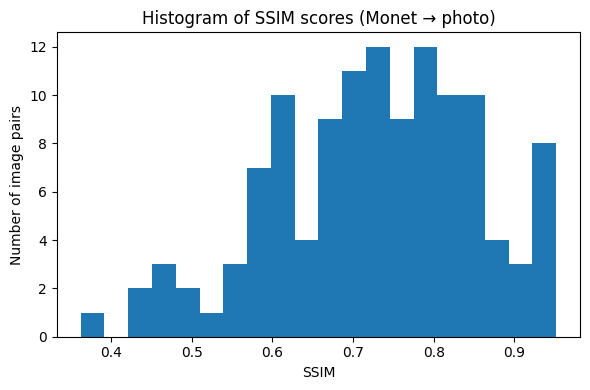


Selected examples:
Low   SSIM  (potentially too far from Monet) : index 115,  SSIM=0.362
Medium SSIM  (ideal?) : index 46, SSIM=0.731
High  SSIM  (too similar to Monet): index 5, SSIM=0.952


In [23]:
import matplotlib.pyplot as plt
from skimage.io import imread

# ssim_scores is currently a Python list -> convert to NumPy array
ssim_scores = np.array(ssim_scores)
mean_ssim = ssim_scores.mean()
std_ssim = ssim_scores.std()
min_ssim = ssim_scores.min()
max_ssim = ssim_scores.max()

print(f"Mean SSIM: {mean_ssim:.3f}")
print(f"Std  SSIM: {std_ssim:.3f}")
print(f"Min  SSIM: {min_ssim:.3f}")
print(f"Max  SSIM: {max_ssim:.3f}")

# Histogram of SSIM scores
plt.figure(figsize=(6, 4))
plt.hist(ssim_scores, bins=20)
plt.xlabel("SSIM")
plt.ylabel("Number of image pairs")
plt.title("Histogram of SSIM scores (Monet → photo)")
plt.tight_layout()
plt.show()

# Find examples of high, medium, low
sorted_idx = np.argsort(ssim_scores)  

low_idx   = sorted_idx[0]                     # lowest SSIM  → potential failure case (too different from Monet)
high_idx  = sorted_idx[-1]                    # highest SSIM → very Monet-like
mid_idx   = sorted_idx[len(sorted_idx) // 2]  # median SSIM → "ideal" zone? tbd

print("\nSelected examples:")
print(f"Low   SSIM  (potentially too far from Monet) : index {low_idx},  SSIM={ssim_scores[low_idx]:.3f}")
print(f"Medium SSIM  (ideal?) : index {mid_idx}, SSIM={ssim_scores[mid_idx]:.3f}")
print(f"High  SSIM  (too similar to Monet): index {high_idx}, SSIM={ssim_scores[high_idx]:.3f}")

Ranges are based on ChatGPT and examples in original paper. Assumptions must be double checked.

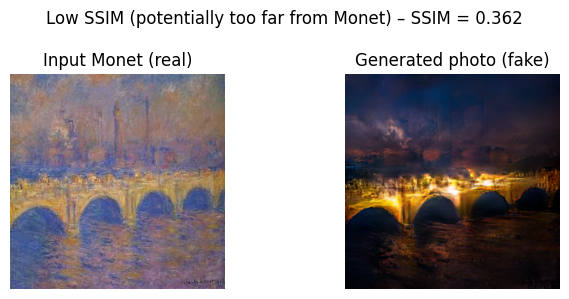

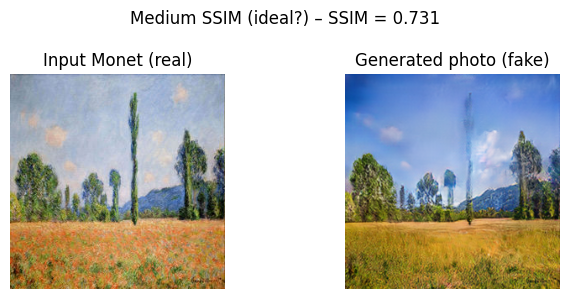

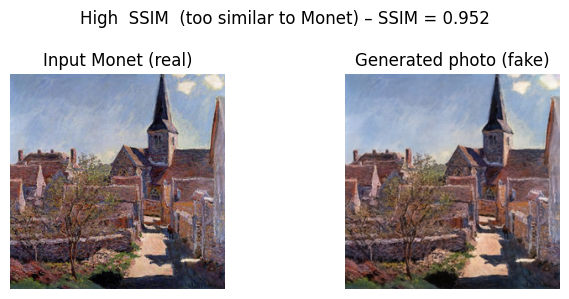

In [24]:
def show_pair(fake_path, real_path, title):
    fake_img = imread(fake_path)
    real_img = imread(real_path)

    fig, axes = plt.subplots(1, 2, figsize=(7, 3))

    axes[0].imshow(real_img)
    axes[0].set_title("Input Monet (real)")
    axes[0].axis("off")

    axes[1].imshow(fake_img)
    axes[1].set_title("Generated photo (fake)")
    axes[1].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_pair(
    *pairs[low_idx],
    title=f"Low SSIM (potentially too far from Monet) – SSIM = {ssim_scores[low_idx]:.3f}"
)

show_pair(
    *pairs[mid_idx],
    title=f"Medium SSIM (ideal?) – SSIM = {ssim_scores[mid_idx]:.3f}"
)

show_pair(
    *pairs[high_idx],
    title=f"High  SSIM  (too similar to Monet) – SSIM = {ssim_scores[high_idx]:.3f}"
)

Takeaway: the results of this SSIM analysis at least gives us initial insights into how much generated images differ from the original monet in the test dataset. It is also clear that we would like to decrease SSIM (it should for sure be not too high as that would mean little change compared to original Monet). We would have to investigate further where exactly we find the sweet spot for ideal SSIM (potentially also in combination with qualitative assessment). 

However, SSIM requires paired images and we are most interested in the similarity between generated photo and actual photos in our test set. Therefore, we have to turn to other metrics that do not require paired images. 

##### Embeddings, global mean difference & visualization

In [30]:
%pip install scikit-learn

  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 23.3 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [31]:
from PIL import Image

import torch
from torch import nn
import torchvision.transforms as T
import torchvision.models as models

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [32]:
base_dir = "/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix"

# generated Monet→photo outputs
fake_dir   = os.path.join(base_dir, "results/monet2photo_pretrained/test_monet_latest/images")

# training Monet paintings (A = 1,072 Monets)
monet_dir  = os.path.join(base_dir, "datasets/monet2photo/trainA")

# training real photos (B = 6,287 photos)
photo_dir  = os.path.join(base_dir, "datasets/monet2photo/trainB")

print(fake_dir)
print(monet_dir)
print(photo_dir)

/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/results/monet2photo_pretrained/test_monet_latest/images
/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/datasets/monet2photo/trainA
/Users/katinkakurz/Desktop/CV Final/Advanced-Machine-Learning-for-Computer-Vision/pytorch-CycleGAN-and-pix2pix/datasets/monet2photo/trainB


In [34]:
rng = np.random.default_rng(42)

max_monet = min(500, len(monet_paths))
max_photo = min(1000, len(photo_paths))

monet_paths_sub = list(rng.choice(monet_paths, size=max_monet, replace=False))
photo_paths_sub = list(rng.choice(photo_paths, size=max_photo, replace=False))

print("Using for embeddings:")
print("  fake  :", len(fake_paths))
print("  monet :", len(monet_paths_sub))
print("  photo :", len(photo_paths_sub))

Using for embeddings:
  fake  : 121
  monet : 500
  photo : 1000


In [39]:
# load pretrained inception v3 and remove classification head
inception = models.inception_v3(
    weights=models.Inception_V3_Weights.IMAGENET1K_V1
    # don't pass aux_logits here
)
inception.fc = nn.Identity()        # now output is 2048-d embedding
inception.eval().to(device)

# transform to what Inception expects: 299x299, normalized
inception_transform = T.Compose([
    T.Resize(299),
    T.CenterCrop(299),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /Users/katinkakurz/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:04<00:00, 23.6MB/s] 


In [40]:
def get_embeddings(image_paths, model, transform, device, batch_size=8):
    all_embs = []
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        imgs = []
        for p in batch_paths:
            img = Image.open(p).convert("RGB")
            imgs.append(transform(img))
        imgs = torch.stack(imgs).to(device)

        with torch.no_grad():
            feats = model(imgs)

        all_embs.append(feats.cpu().numpy())
    return np.concatenate(all_embs, axis=0)


In [41]:
fake_embs  = get_embeddings(fake_paths,       inception, inception_transform, device)
monet_embs = get_embeddings(monet_paths_sub,  inception, inception_transform, device)
photo_embs = get_embeddings(photo_paths_sub,  inception, inception_transform, device)

print(fake_embs.shape, monet_embs.shape, photo_embs.shape)


(121, 2048) (500, 2048) (1000, 2048)


In [42]:
mean_fake  = fake_embs.mean(axis=0)
mean_monet = monet_embs.mean(axis=0)
mean_photo = photo_embs.mean(axis=0)

dist_fake_monet = np.linalg.norm(mean_fake - mean_monet)
dist_fake_photo = np.linalg.norm(mean_fake - mean_photo)

print(f"L2 distance mean(fake)–mean(monet): {dist_fake_monet:.3f}")
print(f"L2 distance mean(fake)–mean(photo): {dist_fake_photo:.3f}")


L2 distance mean(fake)–mean(monet): 4.030
L2 distance mean(fake)–mean(photo): 2.999


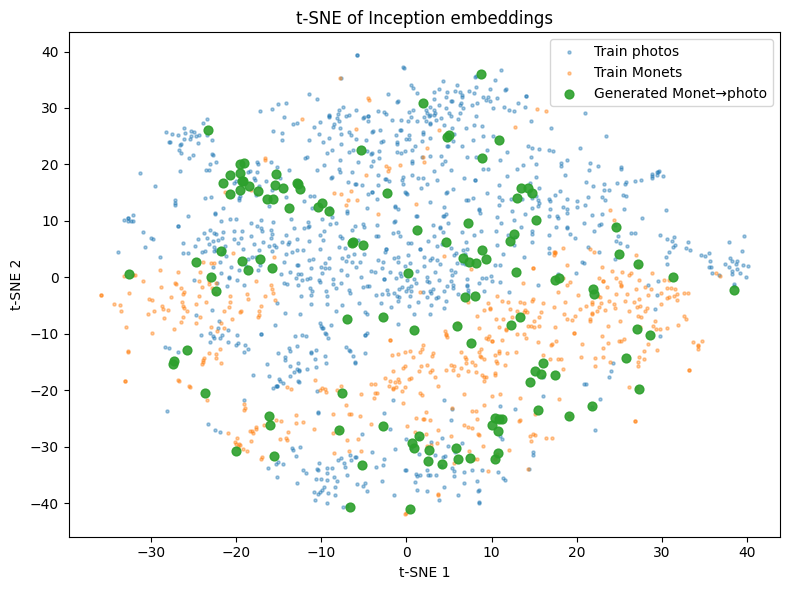

In [43]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X = np.vstack([photo_embs, fake_embs, monet_embs])
labels = (["real photo"] * len(photo_embs) +
          ["generated"]  * len(fake_embs)  +
          ["monet"]      * len(monet_embs))

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42,
)
X_2d = tsne.fit_transform(X)

labels_arr = np.array(labels)
mask_photo = labels_arr == "real photo"
mask_fake  = labels_arr == "generated"
mask_monet = labels_arr == "monet"

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[mask_photo, 0], X_2d[mask_photo, 1], s=5,  alpha=0.4, label="Train photos")
plt.scatter(X_2d[mask_monet, 0], X_2d[mask_monet, 1], s=5,  alpha=0.4, label="Train Monets")
plt.scatter(X_2d[mask_fake,  0], X_2d[mask_fake,  1], s=40, alpha=0.9, label="Generated Monet→photo")

plt.legend()
plt.title("t-SNE of Inception embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()
